# Análisis del Embudo de Conversión de Comercio Electrónico

Este cuaderno realiza un análisis exploratorio de datos sobre un embudo de conversión de comercio electrónico, identificando puntos clave de abandono y factores que influyen en la compra. El objetivo es proporcionar información para optimizar las estrategias de marketing y la experiencia del usuario.

### Carga y Vista Previa de Datos

Cargamos el dataset `ecommerce_funnel.csv` en un DataFrame de pandas y mostramos las primeras filas para una inspección inicial.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("ecommerce_funnel.csv")

df.head()

,session_id,user_id,session_date,source,device,campaign_type,session_time,pages_viewed,viewed_product,added_to_cart,purchased,abandoned,discount_seen,returning_user,weekday
0,1,15796,2025-04-03,organic,desktop,retargeting,489,8,1,0,0,0,0,0,3
1,2,2434,2025-01-21,social,mobile,retargeting,178,6,1,0,0,0,0,0,1
2,3,190,2025-06-24,social,mobile,influencer,161,7,1,0,0,0,0,0,1
3,4,8434,2025-01-09,organic,mobile,influencer,235,5,0,0,0,0,0,0,3
4,5,26532,2025-02-19,social,mobile,awareness,38,2,0,0,0,0,0,0,2


### Exploración Básica de Datos

Verificamos la información del DataFrame (`df.info()`), las estadísticas descriptivas (`df.describe()`) y la presencia de valores nulos (`df.isnull().sum()`).

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   session_id      120000 non-null  int64 
 1   user_id         120000 non-null  int64 
 2   session_date    120000 non-null  object
 3   source          120000 non-null  object
 4   device          120000 non-null  object
 5   campaign_type   120000 non-null  object
 6   session_time    120000 non-null  int64 
 7   pages_viewed    120000 non-null  int64 
 8   viewed_product  120000 non-null  int64 
 9   added_to_cart   120000 non-null  int64 
 10  purchased       120000 non-null  int64 
 11  abandoned       120000 non-null  int64 
 12  discount_seen   120000 non-null  int64 
 13  returning_user  120000 non-null  int64 
 14  weekday         120000 non-null  int64 
dtypes: int64(11), object(4)
memory usage: 13.7+ MB


,0
session_id,0
user_id,0
session_date,0
source,0
device,0
campaign_type,0
session_time,0
pages_viewed,0
viewed_product,0
added_to_cart,0


### Cálculo de Eventos Clave

Contamos el número total de visitas (`V`), visualizaciones de producto (`P`), adiciones al carrito (`C`) y compras completadas (`B`), además de abandonos (`A`).

El dataset contiene información a nivel de sesión de usuario, incluyendo variables de comportamiento (tiempo en sitio, páginas vistas), características del usuario (dispositivo, recurrencia) y variables de conversión (visualización de producto, carrito y compra).

In [4]:
V = len(df)
P = df['viewed_product'].sum()
C = df['added_to_cart'].sum()
B = df['purchased'].sum()
A = df['abandoned'].sum()

### Cálculo de Tasas de Conversión

Calculamos las tasas de conversión entre las diferentes etapas del embudo: Visitas a Producto, Producto a Carrito y Carrito a Compra.

In [5]:
conversion_VP = P / V
conversion_PC = C / P
conversion_CB = B / C

print(conversion_VP, conversion_PC, conversion_CB)

0.60685 0.2673367938260416 0.098469282925827


### Cálculo de Tasas de Abandono

Determinamos las tasas de abandono en cada transición del embudo (Visita a Producto, Producto a Carrito, Carrito a Compra) para identificar los cuellos de botella.

## INTERPRETACIÓN

*   La tasa de conversión de visitas a producto es de 0.60685.
*   La conversión de producto a carrito es de 0.2673367938260416.
*   La conversión de carrito a compra es de 0.098469282925827.

Se observa que la mayor caída ocurre en **carrito a compra**, lo que indica un cuello de botella en esta etapa.

In [6]:
drop_VP = 1 - conversion_VP
drop_PC = 1 - conversion_PC
drop_CB = 1 - conversion_CB
print (drop_VP, drop_PC, drop_CB)

0.39315 0.7326632061739584 0.901530717074173


### Análisis de Conversión por Dispositivo

Agrupamos los datos por tipo de dispositivo para observar cómo varían las tasas de visualización de producto, adición al carrito y compra.

El mayor porcentaje de abandono se presenta en la transición de **carrito a compra**, lo que sugiere que los usuarios no encuentran suficiente valor o confianza para avanzar.

In [7]:
df.groupby('device')[['viewed_product','added_to_cart','purchased']].mean()

,viewed_product,added_to_cart,purchased
device,,,
desktop,0.609770,0.164061,0.019686
mobile,0.605304,0.161665,0.014300
tablet,0.607948,0.159873,0.015158


### Análisis de Conversión por Fuente de Tráfico

Examinamos la tasa de compra promedio según la fuente de tráfico de la sesión para identificar los canales más efectivos.

### Interpretación del Análisis por Dispositivo

Se observa una ligera mayor tasa de compra en dispositivos de escritorio (0.019686) en comparación con móvil (0.014300) y tablet (0.015158). Esto podría indicar que los usuarios de escritorio están más propensos a completar una compra.

In [8]:
df.groupby('source')[['purchased']].mean()

,purchased
source,
direct,0.013264
email,0.038476
organic,0.015631
paid_ads,0.015403
referral,0.012637
social,0.009720


### Análisis de Conversión por Usuario Recurrente

Comparamos las tasas de compra entre usuarios nuevos y recurrentes para entender su impacto en la conversión.

### Interpretación del Análisis por Fuente de Tráfico

La fuente `email` tiene la tasa de compra más alta (0.038476), lo que sugiere que las campañas de correo electrónico son muy efectivas en la conversión. `Social` es la fuente con la tasa de compra más baja (0.009720).

In [9]:
df.groupby('returning_user')[['purchased']].mean()

,purchased
returning_user,
0,0.009866
1,0.027296


### Análisis de Conversión por Descuento Visto

Investigamos si la visualización de un descuento influye en la tasa de compra.

### Interpretación del Análisis por Usuario Recurrente

Los usuarios recurrentes (`returning_user` = 1) tienen una tasa de compra significativamente mayor (0.027296) que los usuarios nuevos (0.009866), lo cual es esperado ya que tienen familiaridad con el sitio.

In [10]:
df.groupby('discount_seen')[['purchased']].mean()

,purchased
discount_seen,
0,0.014502
1,0.019450


### Preparación de Datos para el Modelo Predictivo

Copiamos el DataFrame original y codificamos las variables categóricas (`device`, `source`, `campaign_type`) usando `LabelEncoder` para prepararlas para el modelado.

# Fase 2
Modelo Predictivo

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Codificar variables categóricas
categorical_cols = ['device', 'source', 'campaign_type']

le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

### Definición de Características (Features)

Definimos las columnas que se utilizarán como características (`X`) en los modelos predictivos.

In [12]:
features = [
    'device',
    'source',
    'campaign_type',
    'returning_user',
    'pages_viewed',
    'session_time',
    'discount_seen'
]

X = df_model[features]

### Modelo Predictivo: Visualización de Producto

Entrenamos un modelo `GaussianNB` para predecir si un usuario verá un producto. Dividimos los datos en conjuntos de entrenamiento y prueba, ajustamos el modelo y evaluamos su rendimiento.

In [13]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

y1 = df_model['viewed_product']

X_train, X_test, y_train, y_test = train_test_split(X, y1, test_size=0.3, random_state=42)

model_vp = GaussianNB()
model_vp.fit(X_train, y_train)

y_pred = model_vp.predict(X_test)

print("Modelo Ver Producto")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Modelo Ver Producto
Accuracy: 0.6099166666666667
              precision    recall  f1-score   support

           0       0.52      0.01      0.02     14053
           1       0.61      1.00      0.76     21947

    accuracy                           0.61     36000
   macro avg       0.57      0.50      0.39     36000
weighted avg       0.58      0.61      0.47     36000



### Modelo Predictivo: Adición al Carrito

Entrenamos un modelo `GaussianNB` similar para predecir si un usuario añadirá un producto al carrito, siguiendo los mismos pasos de división y evaluación.

In [14]:
y2 = df_model['added_to_cart']

X_train, X_test, y_train, y_test = train_test_split(X, y2, test_size=0.3, random_state=42)

model_pc = GaussianNB()
model_pc.fit(X_train, y_train)

y_pred = model_pc.predict(X_test)

print("Modelo Carrito")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Modelo Carrito
Accuracy: 0.8386944444444444
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     30193
           1       0.00      0.00      0.00      5807

    accuracy                           0.84     36000
   macro avg       0.42      0.50      0.46     36000
weighted avg       0.70      0.84      0.77     36000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Modelo Predictivo: Compra

Entrenamos un modelo `GaussianNB` para predecir la compra final, con la misma metodología de entrenamiento y evaluación.

In [15]:
y3 = df_model['purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y3, test_size=0.3, random_state=42)

model_cb = GaussianNB()
model_cb.fit(X_train, y_train)

y_pred = model_cb.predict(X_test)

print("Modelo Compra")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Modelo Compra
Accuracy: 0.9843333333333333
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     35436
           1       0.00      0.00      0.00       564

    accuracy                           0.98     36000
   macro avg       0.49      0.50      0.50     36000
weighted avg       0.97      0.98      0.98     36000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Cálculo de Probabilidades de Predicción

Calculamos las probabilidades de predicción para cada etapa del embudo (ver producto, añadir al carrito, comprar) utilizando los modelos entrenados.

In [16]:
probs_vp = model_vp.predict_proba(X_test)
probs_pc = model_pc.predict_proba(X_test)
probs_cb = model_cb.predict_proba(X_test)

In [17]:
lambda_VP = probs_vp[:,1].mean()
lambda_PC = probs_pc[:,1].mean()
lambda_CB = probs_cb[:,1].mean()

print(lambda_VP, lambda_PC, lambda_CB)

0.6057224628797612 0.16384707638544083 0.016335038335944036


In [18]:
import numpy as np

importance = np.abs(model_cb.theta_[1] - model_cb.theta_[0])
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
5,session_time,3.086495
1,source,0.412019
3,returning_user,0.242321
0,device,0.075383
6,discount_seen,0.070128
4,pages_viewed,0.036543
2,campaign_type,0.022600


### Resultados obtenidos

A partir del modelo Naive Bayes, se obtuvieron las siguientes tasas de transición:

- λ_VP = 0.6057  
- λ_PC = 0.1638  
- λ_CB = 0.0163  

---

### Interpretación

Estos valores indican que, en promedio:

- Aproximadamente el 60.57% de los usuarios visualizan un producto
- El 16.38% de los usuarios agregan un producto al carrito
- Solo el 1.63% de los usuarios completan la compra

Esto evidencia una caída significativa a lo largo del funnel, especialmente en la transición hacia la compra.

---

### Consistencia con el análisis exploratorio

Las tasas obtenidas son coherentes con las observadas en la Fase 1, donde ya se identificaba una pérdida considerable de usuarios en las etapas finales del funnel. Esto valida la relación entre el análisis descriptivo y el modelo probabilístico.

---

### Interpretación del modelo

El uso del valor esperado permite capturar la heterogeneidad de los usuarios en una única métrica agregada, facilitando su incorporación en el modelo dinámico.

Además, los resultados muestran que la probabilidad de compra es considerablemente baja en comparación con las etapas anteriores, lo que sugiere que el principal problema del negocio no es la atracción de usuarios, sino la conversión final.

---

### Insight clave

El funnel presenta su mayor cuello de botella en la transición de carrito a compra, lo que indica oportunidades de mejora en factores como confianza, experiencia de usuario, costos finales o procesos de pago.

# Fase 4: Modelo Dinámico del Funnel

## Definición del sistema

A partir de las tasas obtenidas en la fase anterior, se construye un sistema de ecuaciones diferenciales que modela la evolución del funnel en el tiempo.

Se definen las siguientes variables de estado:

- V(t): número de visitas
- P(t): usuarios que ven productos
- C(t): usuarios que agregan al carrito
- B(t): usuarios que compran
- A(t): usuarios que abandonan

---

## Sistema de ecuaciones

El sistema dinámico se define como:

- dV/dt = -λ_VP · V  
- dP/dt = λ_VP · V - λ_PC · P  
- dC/dt = λ_PC · P - (λ_CB + λ_CA) · C  
- dB/dt = λ_CB · C  
- dA/dt = λ_CA · C  

donde:

- λ_VP = 0.6057  
- λ_PC = 0.1638  
- λ_CB = 0.0163  
- λ_CA = tasa de abandono desde carrito

---

El sistema modela el flujo de usuarios entre etapas del funnel como un proceso dinámico continuo, donde cada tasa representa la velocidad de transición entre estados.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [20]:
lambda_VP = 0.6057
lambda_PC = 0.1638
lambda_CB = 0.0163

# Asumimos abandono (puedes ajustar esto luego)
lambda_CA = 0.10

In [21]:
def funnel_system(y, t, lambda_VP, lambda_PC, lambda_CB, lambda_CA):
    V, P, C, B, A = y

    dVdt = -lambda_VP * V
    dPdt = lambda_VP * V - lambda_PC * P
    dCdt = lambda_PC * P - (lambda_CB + lambda_CA) * C
    dBdt = lambda_CB * C
    dAdt = lambda_CA * C

    return [dVdt, dPdt, dCdt, dBdt, dAdt]

In [22]:
V0 = 10000   # visitas iniciales
P0 = 0
C0 = 0
B0 = 0
A0 = 0

y0 = [V0, P0, C0, B0, A0]

In [23]:
t = np.linspace(0, 10, 100)

solution = odeint(
    funnel_system,
    y0,
    t,
    args=(lambda_VP, lambda_PC, lambda_CB, lambda_CA)
)

V, P, C, B, A = solution.T

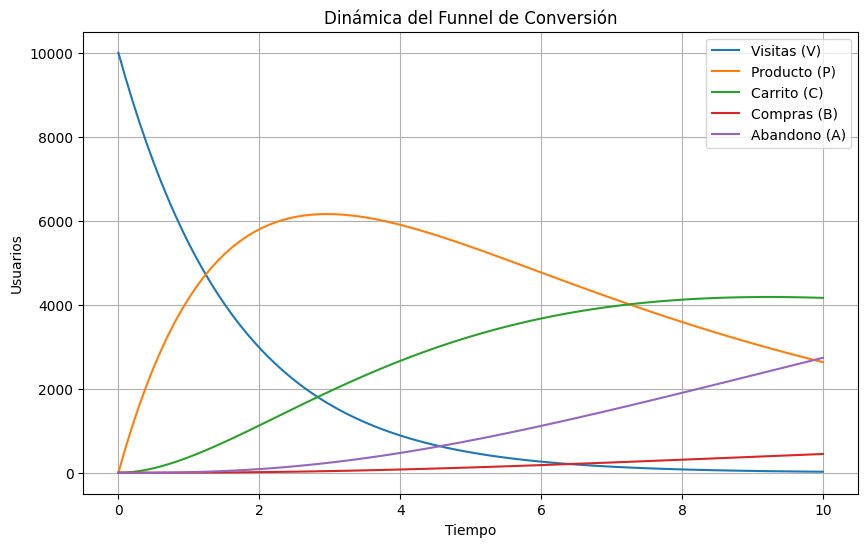

In [24]:
plt.figure(figsize=(10,6))

plt.plot(t, V, label='Visitas (V)')
plt.plot(t, P, label='Producto (P)')
plt.plot(t, C, label='Carrito (C)')
plt.plot(t, B, label='Compras (B)')
plt.plot(t, A, label='Abandono (A)')

plt.xlabel('Tiempo')
plt.ylabel('Usuarios')
plt.title('Dinámica del Funnel de Conversión')
plt.legend()
plt.grid()

plt.show()

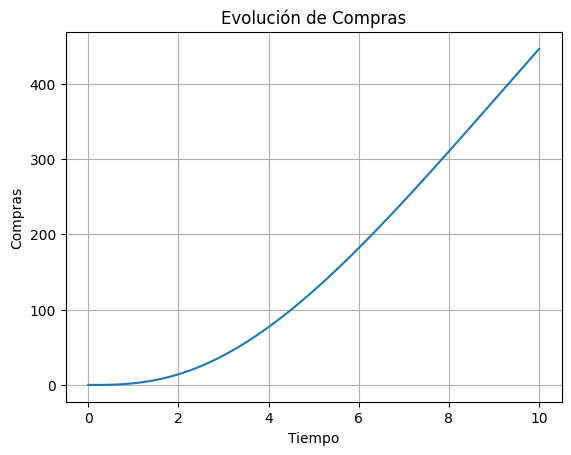

In [25]:
plt.figure()

plt.plot(t, B)

plt.xlabel('Tiempo')
plt.ylabel('Compras')
plt.title('Evolución de Compras')

plt.grid()
plt.show()

## Interpretación de resultados

La simulación muestra cómo los usuarios fluyen a través del funnel a lo largo del tiempo.

Se observa que:

- La mayoría de los usuarios se concentran en las primeras etapas del funnel
- Existe una disminución progresiva hacia la etapa de compra
- El número de compras crece lentamente en comparación con el volumen de visitas

Esto confirma que el sistema presenta una baja eficiencia de conversión, especialmente en las etapas finales.

---

## Insight clave

El modelo evidencia que el principal problema del negocio no es la generación de tráfico, sino la conversión efectiva de usuarios en compradores.

---

## Valor del modelo

Este enfoque permite simular escenarios y evaluar el impacto de cambios en las tasas de conversión, facilitando la toma de decisiones estratégicas.

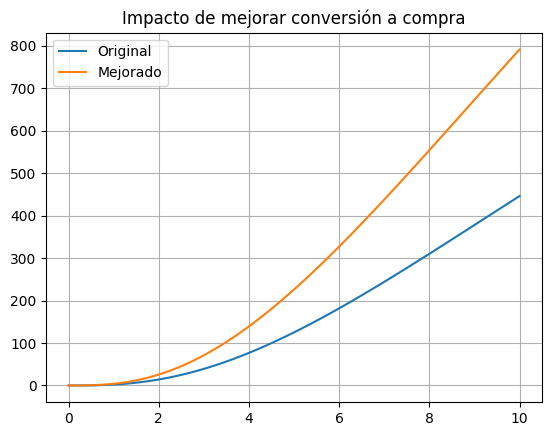

In [26]:
lambda_CB_new = 0.03  # mejora

solution2 = odeint(
    funnel_system,
    y0,
    t,
    args=(lambda_VP, lambda_PC, lambda_CB_new, lambda_CA)
)

_, _, _, B2, _ = solution2.T

plt.figure()

plt.plot(t, B, label='Original')
plt.plot(t, B2, label='Mejorado')

plt.legend()
plt.title('Impacto de mejorar conversión a compra')
plt.grid()

plt.show()

Un incremento en la tasa de compra genera un aumento significativo en el número final de conversiones, sin necesidad de incrementar el tráfico.

Esto sugiere que optimizar la conversión es más eficiente que invertir en adquisición de usuarios.